In [1]:
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import geometry
import shapely
from matplotlib_scalebar.scalebar import ScaleBar
import os
import matplotlib as mpl
import sys
sys.path.append('/Users/amossi/Documents/code/')
import FISHspace as sp

# make font changeable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2
%load_ext autoreload
%autoreload 2

/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

In [2]:
from FISHscale.utils.dataset import Dataset

INFO:root:Please install "BoneFight" or its missing dependencies. Error message: No module named 'bone_fight'
INFO:root:Could not import Cellpose. Ignore if cell segmentation is not needed. Error: No module named 'cellpose'


In [ ]:
#adata = sc.read_h5ad('../../EEL_AnnData/EEL_41CleanNuclei-CellularNgh_FeaturesMN.h5ad')
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)
adata.obs['m-states'] = pd.Categorical(['Mural' if x.count('Mural') else x for x in adata.obs['m-states']])


In [4]:
palette_colors = {
    'WR 2': '#EDE8F3',
    'WR 3': '#E2D8EA',
    'WR 1': '#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 7': '#e43c96',
    'WR 8': '#C50F53',
    'WR 4': '#A40447',
    'WR 6': '#840034',
    
    'Endothelial':'#d5b8ff', # '#d5b8ff',  
    'Mural': '#d5b8ff',#'#8c14fc',
}


In [5]:
from PIL import Image
HE_SL035B = Image.open("HE_035B_1_aligned_5d.tif")

In [6]:
palette_GW = {
    'WR 2': '#f4efef',#'#EDE8F3',
    'WR 3': '#f4efef',#'#E2D8EA',
    'WR 1': '#f4efef',#'#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 7': '#e43c96',
    'WR 8': '#C50F53',
    'WR 4': '#A40447',
    'WR 6': '#840034',
    
    'Endothelial':'#8c14fc', # '#d5b8ff',  
    'Mural': '#8c14fc',
    
    'nIPC-RG-like':'#7dfee3',
    'FB-like 3': '#9f5afd',#'#ff9470',
    
}

palette_GW2 = {
    'WR 1': '#C42AC9',#'#D6BEDD',
    'WR 8': '#D19185',
    'WR 6': '#C50F53',
    
    'Endothelial':'#35F5B7', # '#d5b8ff',  
    'Mural': '#00C75D',
    
    'nIPC-RG-like':'#C8E683',
    'FB-like 3': '#C8E683',#'#ff9470',
    
}



2025-10-28 14:17:42,193 - INFO - First filter, 15126 cells left
2025-10-28 14:17:42,398 - INFO - Selecting cells in zoom area
2025-10-28 14:17:42,551 - INFO - Zoom filter, 280 cells left


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


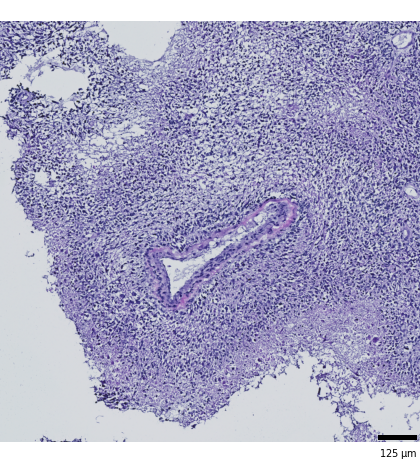

In [7]:
fig,ax = plt.subplots(1,1 ,figsize=(5,5))
xlim = (8150,9150)
ylim=(4000,5000)
sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    cluster_key='m-states',
    clusters=['WR 5'],
    show_axis=False,
    palette= palette_GW,
    image=np.array(HE_SL035B),
    xlim=xlim,
    ylim=ylim,
    #flipy=False,
    #save = True,
    #savepath='figures/SL035B.svg',
    alpha=0,
    ax=ax
)

plt.savefig('figures/SL035B_HE_zoom.png',dpi=300, format='png',bbox_inches='tight')
plt.show()


In [8]:
import seaborn as sns
from matplotlib.colors import rgb2hex
sns.color_palette("PuRd", 12)
#GW1, GW2, GW3 = '#f4efef', '#f4efef', '#f4efef'

[(0.9312264513648597, 0.9124490580545944, 0.9530949634755863),
 (0.8892272202998847, 0.8472895040369088, 0.9188465974625144),
 (0.8424759707804691, 0.7488658208381391, 0.8671741637831603),
 (0.8120876585928489, 0.6606228373702422, 0.8215916955017301),
 (0.7946635909265667, 0.5666589773164169, 0.7736716647443291),
 (0.84879661668589, 0.45101114955786237, 0.7170780469050365),
 (0.8838600538254517, 0.3259515570934256, 0.6457823913879277),
 (0.9035447904652056, 0.17831603229527104, 0.5522798923490965),
 (0.8516724336793541, 0.11091118800461361, 0.42841983852364474),
 (0.7762860438292967, 0.0600692041522492, 0.3261514801999232),
 (0.6434140715109573, 0.015778546712802766, 0.2794002306805075),
 (0.5184621299500192, 0.0, 0.2057208765859285)]

In [9]:
palette_GW = {
    'WR 2': '#EDE8F3',
    'WR 3': '#E2D8EA',
    'WR 1': '#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 7': '#e43c96',
    'WR 8': '#C50F53',
    'WR 4': '#A40447',
    'WR 6': '#840034',
    
    'Endothelial':'#C8E683', # '#d5b8ff',  
    'Mural': '#C8E683',
    
    'nIPC-RG-like':'#7dfee3',
    'FB-like 3': '#9f5afd',#'#ff9470',
    
}

2025-10-28 14:17:49,107 - INFO - First filter, 160441 cells left
2025-10-28 14:17:49,478 - INFO - Selecting cells in zoom area
2025-10-28 14:17:50,846 - INFO - Zoom filter, 1901 cells left


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


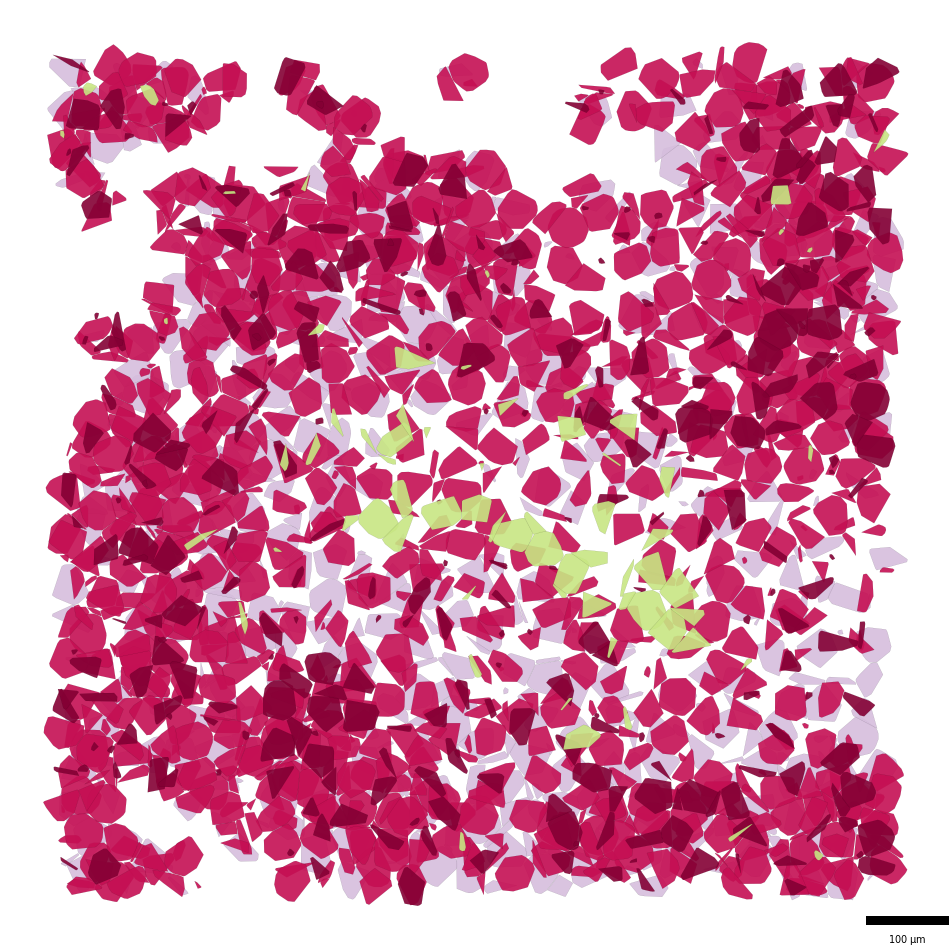

In [10]:
palette_colors = {
    'WR 2': '#60AFFF',
    'WR 3': '#93faa5',
    #'WR 1': '#87d37c',#'#8AFFC1',
    'WR 1': '#93faa5',#'#8AFFC1',
    'WR 5': '#1ba39c',
    'WR 7': '#e43c96',
    'WR 8': '#a2d2ff', #blue
    #'WR 8': '#efcfe3',
    'WR 4': '#A40447',
    'WR 6': '#f62459',#'#840034',
    
    'Endothelial':'#fef160', # '#d5b8ff',  
    'Mural': '#d5b8ff',

    'nIPC-RG-like':'#7dfee3',
    'FB-like 3': '#9f5afd',#'#ff9470',
}

palette_GW = {
    'WR 2': '#EDE8F3',
    'WR 3': '#E2D8EA',
    'WR 1': '#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 7': '#e43c96',
    'WR 8': '#C50F53',
    'WR 4': '#A40447',
    'WR 6': '#840034',
    
    'Endothelial':'#C8E683', # '#d5b8ff',  
    'Mural': '#C8E683',
    
    'nIPC-RG-like':'#7dfee3',
    'FB-like 3': '#9f5afd',#'#ff9470',
    
}

fig,ax = plt.subplots(1,1 ,figsize=(10,10))
xlim = (11200, 12200)
ylim= (5500, 6500)

sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    cluster_key='m-states',
    clusters=['WR 1','WR 8','WR 6','Endothelial'], 
    show_axis=False,
    palette= palette_GW,
    #image=np.array(HE_SL035B),
    xlim=xlim,
    ylim=ylim,
    #flipy=False,
    #save = True,
    #savepath='figures/SL035B.svg',
    alpha=0.9,
    ax=ax
)

plt.savefig('figures/SL035B_zoom.svg',dpi=300, format='png',bbox_inches='tight')
plt.show()

2025-10-28 14:17:55,578 - INFO - First filter, 160441 cells left
2025-10-28 14:17:55,957 - INFO - Selecting cells in zoom area
2025-10-28 14:17:57,612 - INFO - Zoom filter, 6583 cells left


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


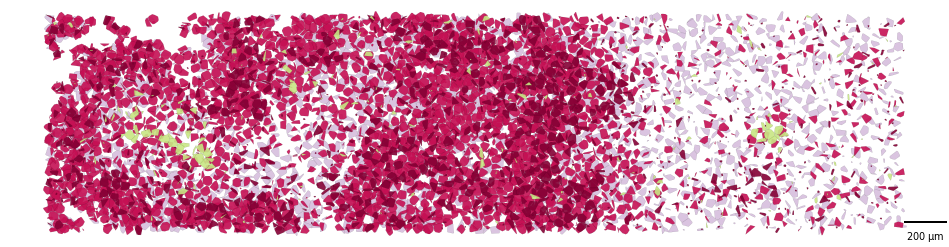

In [12]:
palette_GW = {
    'WR 2': '#EDE8F3',
    'WR 3': '#E2D8EA',
    'WR 1': '#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 7': '#e43c96',
    'WR 8': '#C50F53',
    'WR 4': '#A40447',
    'WR 6': '#840034',
    
    'Endothelial':'#C8E683', # '#d5b8ff',  
    'Mural': '#C8E683',
    
    'nIPC-RG-like':'#7dfee3',
    'FB-like 3': '#9f5afd',#'#ff9470',
    
}

fig,ax = plt.subplots(1,1 ,figsize=(10,10))
xlim = (11200, 15200)
ylim= (5500, 6500)

sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    cluster_key='m-states',
    clusters=['WR 1','WR 8','WR 6','Endothelial'], 
    show_axis=False,
    palette= palette_GW,
    #image=np.array(HE_SL035B),
    xlim=xlim,
    ylim=ylim,
    #flipy=False,
    #save = True,
    #savepath='figures/SL035B.svg',
    alpha=0.9,
    ax=ax
)

plt.savefig('figures/SL035B_zoom2.svg',dpi=300, format='png',bbox_inches='tight')
plt.show()

In [ ]:

SL035B = Dataset('../../data_for_visualization/AMEXP20220524_EEL_SL035B_S2_RNA_transformed_assigned.parquet',
             gene_label='decoded_genes',
             pixel_size='0.27 micrometers',
             reparse=True,
            )


 99%|█████████████████████████████████████▊| 1316/1324 [00:09<00:00, 105.48it/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████████████████████████████████| 1324/1324 [00:09<00:00, 135.04it/s]


2025-10-28 14:18:50,309 - INFO -     Auto loading color dictionary failed, generating new color dictionary.
2025-10-28 14:18:50,318 - INFO -     Generated new color dictionary and saved as: /Users/amossi/Documents/Karolinska/glioblastoma_wound_response/Example_Notebooks/Extended Data Figure 7/AMEXP20220524_EEL_SL035B_S2_RNA_transformed_assigned_FISHscale_Data/AMEXP20220524_EEL_SL035B_S2_RNA_transformed_assigned_color_dictionary.pkl
2025-10-28 14:18:50,318 - INFO -     Loaded: AMEXP20220524_EEL_SL035B_S2_RNA_transformed_assigned


"SL020color_dict['VEGFA'] = np.array((227, 61, 148)) / 255\nSL020color_dict['FTL'] = np.array((255, 255, 204)) / 255\nSL020color_dict['IGFBP5'] = np.array((210, 77, 87)) / 255"

In [15]:
import matplotlib.colors as mcolors
#SL020.color_dict['EGFR'] = mcolors.to_rgb(cluster_colors_GBM['preOPC-like 1'])
SL035B.color_dict['GFAP'] = mcolors.to_rgb('#93faa5')
SL035B.color_dict['COL1A1'] = mcolors.to_rgb('#89c4f4')
SL035B.color_dict['RGCC'] = mcolors.to_rgb('#f1e7fe')

SL035B.color_dict['FN1'] = mcolors.to_rgb('#d5b8ff')
SL035B.color_dict['TNC'] = mcolors.to_rgb('#e33d94')
SL035B.color_dict['VEGFA'] = mcolors.to_rgb(palette_GW['WR 6'])

AttributeError: 'Legend' object has no attribute 'legendHandles'

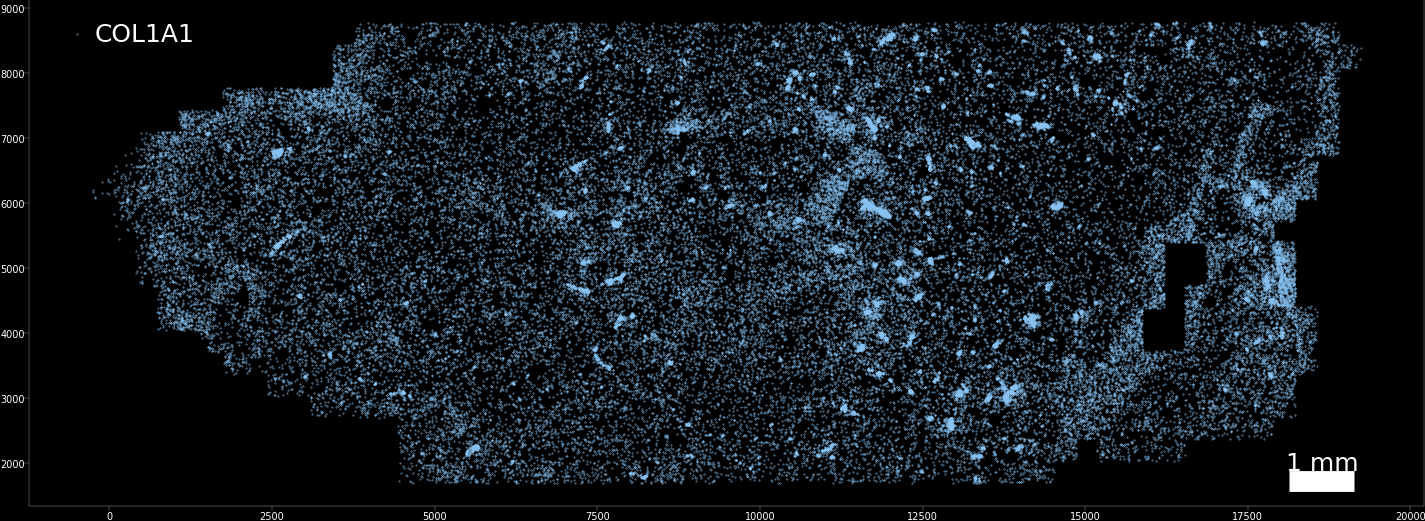

In [16]:
SL035B.scatter_plot(
    'COL1A1',
    ax_scale_factor=50,
    show_axes=True,
)

In [ ]:
import zarr
from skimage import img_as_bool
from skimage.transform import rescale
from skimage import util
img = zarr.load('../../data_for_visualization/AMEXP20220524_EEL_SL035B_S2_image_segmented_labels.zarr')
#img = np.flip(img, axis=0)

In [ ]:
img[img >0] = 1
img_d = rescale(img, 0.27, anti_aliasing=False)
img_d[img_d >0] = 1
img_d = img_as_bool(img_d)
#x1, y1, x2, y2 = x1*0.27, y1*0.27, x2*0.27, y2*0.27
img_SL035B = img_d

In [57]:
SL035B.color_dict['COL1A1'] = '#fffc7f'#palette_GW['FB-like 3']
SL035B.color_dict['RGCC'] = '#c5eff7'#'#89c4f4'
SL035B.color_dict['VEGFA'] = '#e76d89'#palette_GW['WR 7']
SL035B.color_dict['MGP'] = '#d5b8ff' #palette_GW['WR 5']
SL035B.color_dict['FN1'] = '#c3ff68' #palette_GW['Endothelial']
SL035B.color_dict['AQP4'] =  '#26c281'
SL035B.color_dict['PTPRZ1'] =  '#93faa5'
SL035B.color_dict['S100B'] =  '#c2f970'

AttributeError: 'Legend' object has no attribute 'legendHandles'

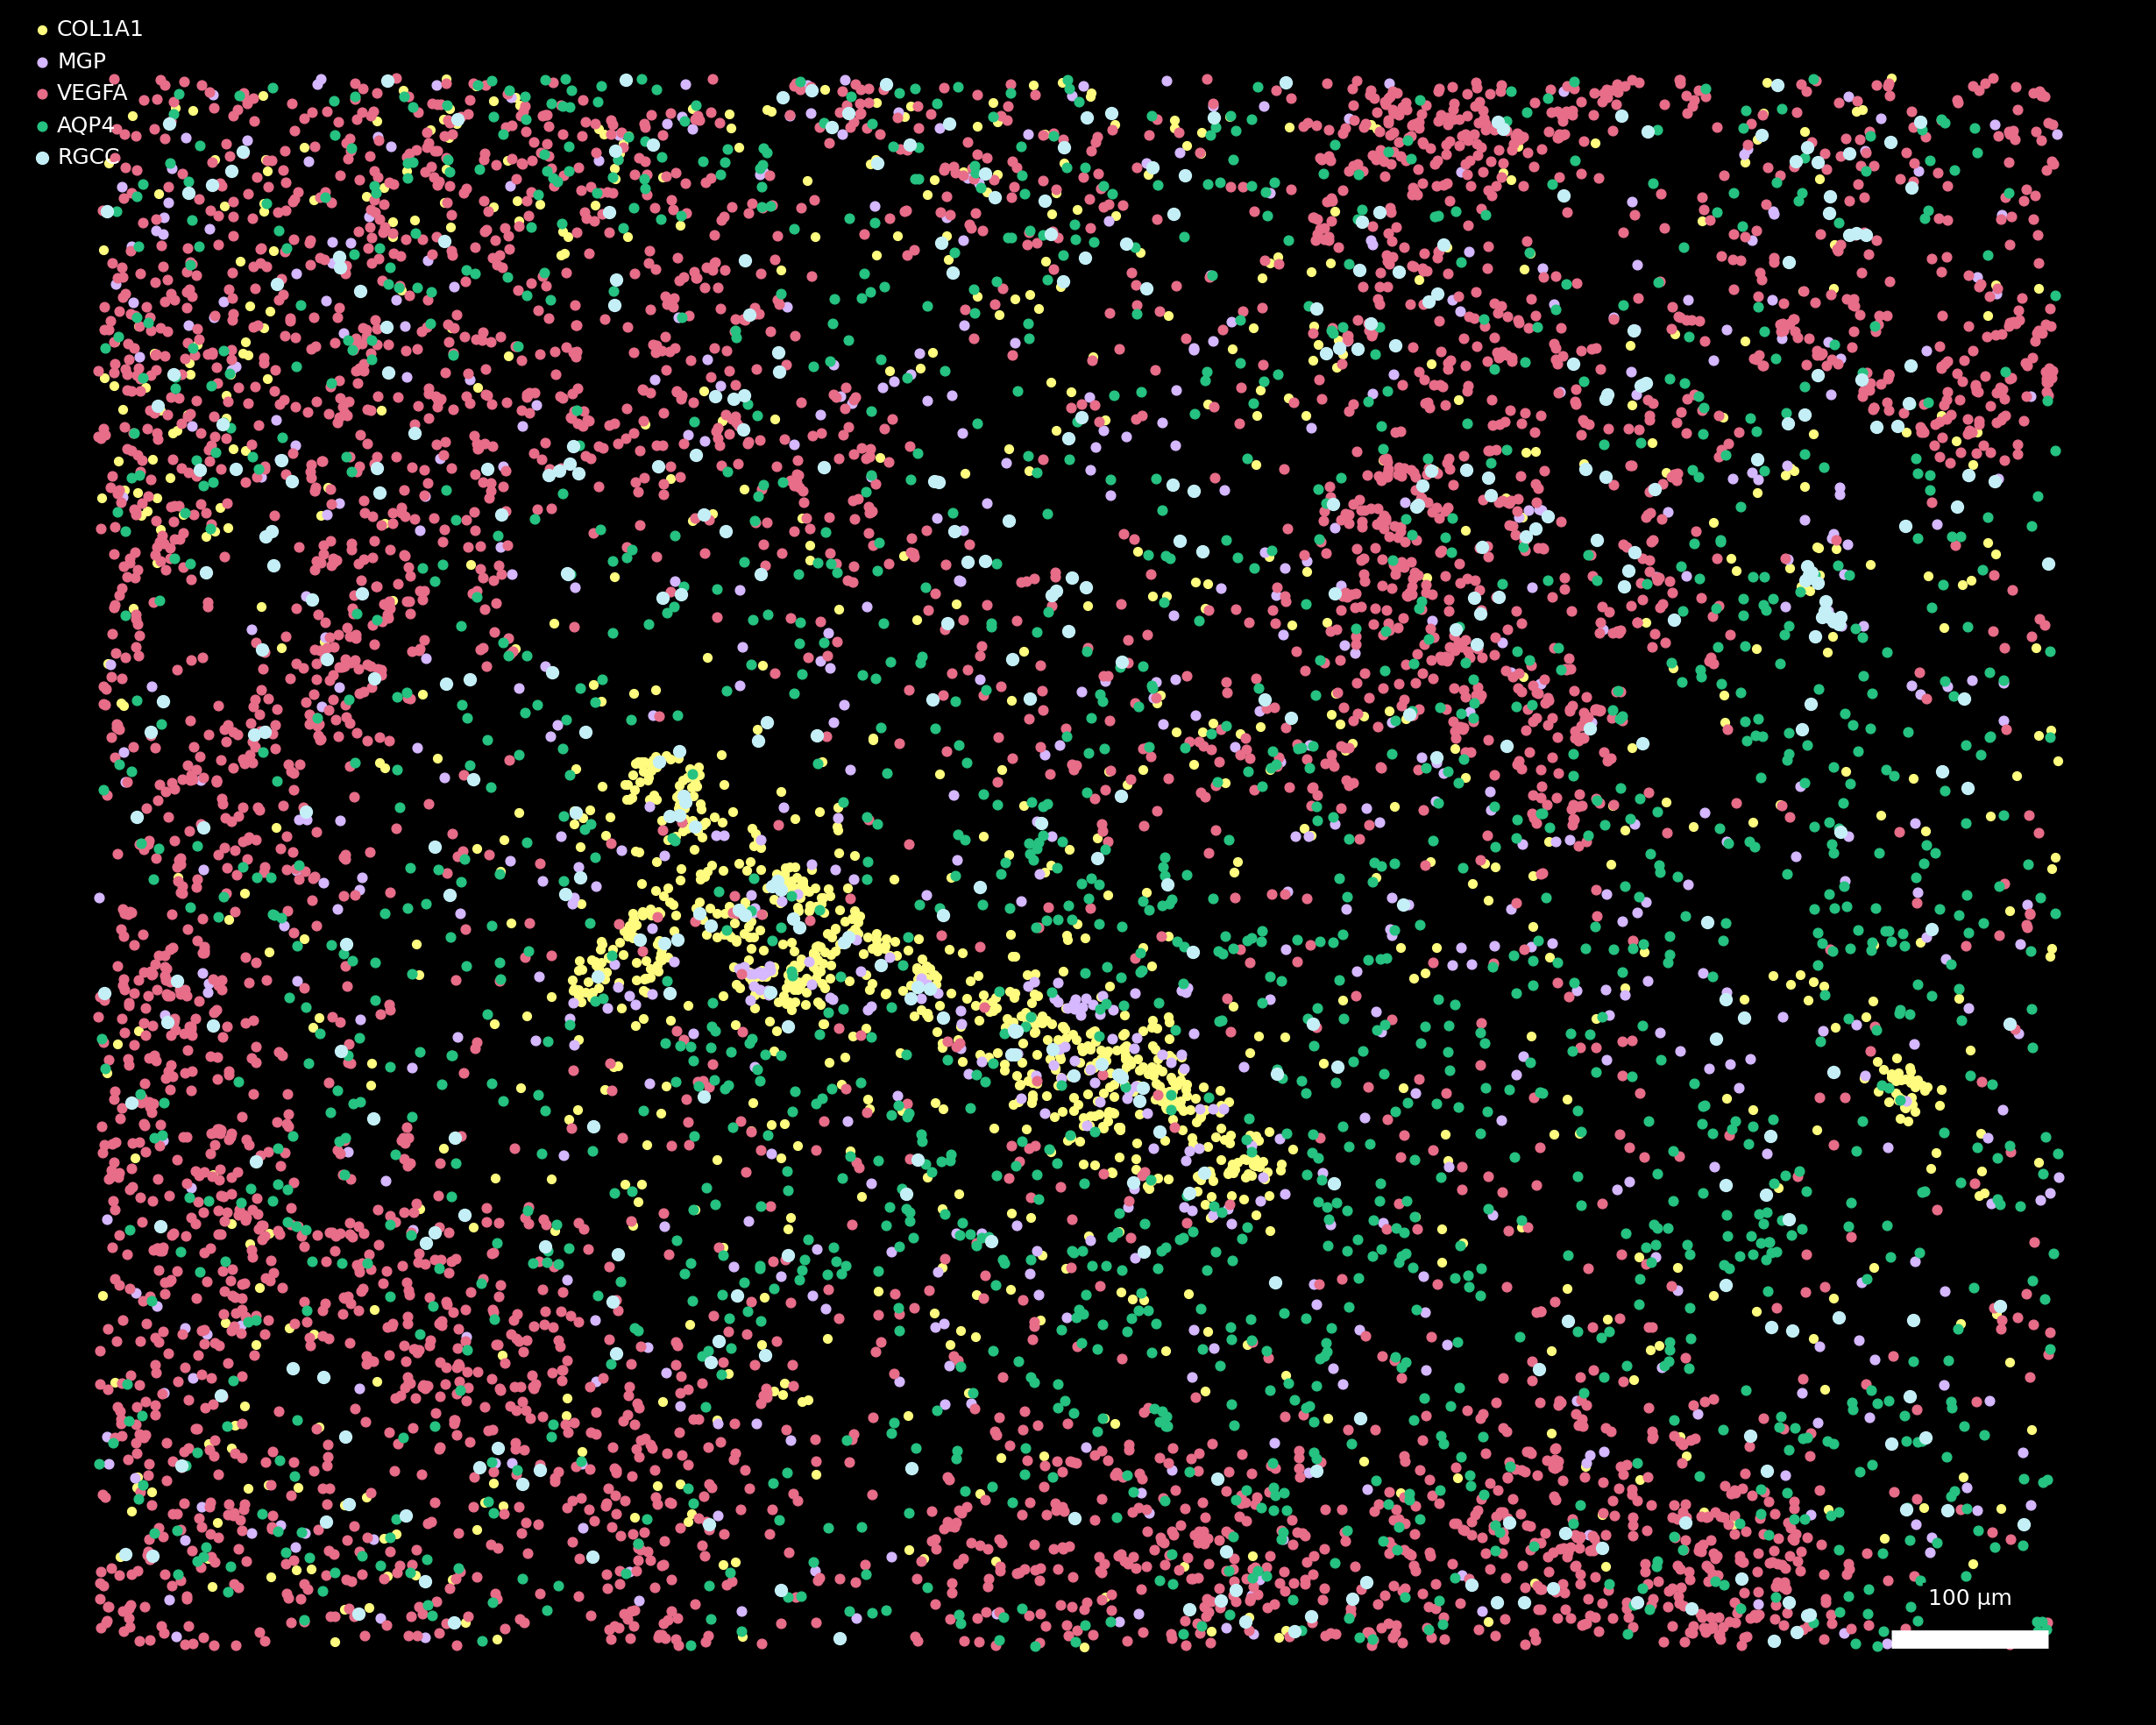

In [59]:
xlim= (11250,12500)
ylim= (5500,6500)
v =  [[xlim[0], ylim[0]],[xlim[1],ylim[1]]]

scale_factor = 1#0.27*4.5
#img_zoom = img_SL035B[int(v[0][1]*scale_factor):int(v[1][1]*scale_factor),int(v[0][0]*scale_factor):int(v[1][0]*scale_factor)]

sizes = [50, 60, 60, 60,100] 
genes = ['COL1A1', 'MGP','VEGFA','AQP4', 'RGCC']
SL035B.scatter_plot(
    genes,
    s=sizes,
    ax_scale_factor=500,
    show_axes=False,
    show_legend=True,
    view = v,
    #image=img_zoom,
    alpha_img=1,
    reset_xy=True,
    save=True,
    save_name='figures/SL035B_zoom_dots.svg'
)

# SL020

In [62]:
from PIL import Image
HE_SL020 = Image.open("HE_020_0_aligned_5d.tif")

In [63]:
np.array(HE_SL020).shape

(4304, 8193, 3)

2025-10-28 14:25:32,697 - INFO - First filter, 1428 cells left
2025-10-28 14:25:32,866 - INFO - Zoom filter, 1428 cells left


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


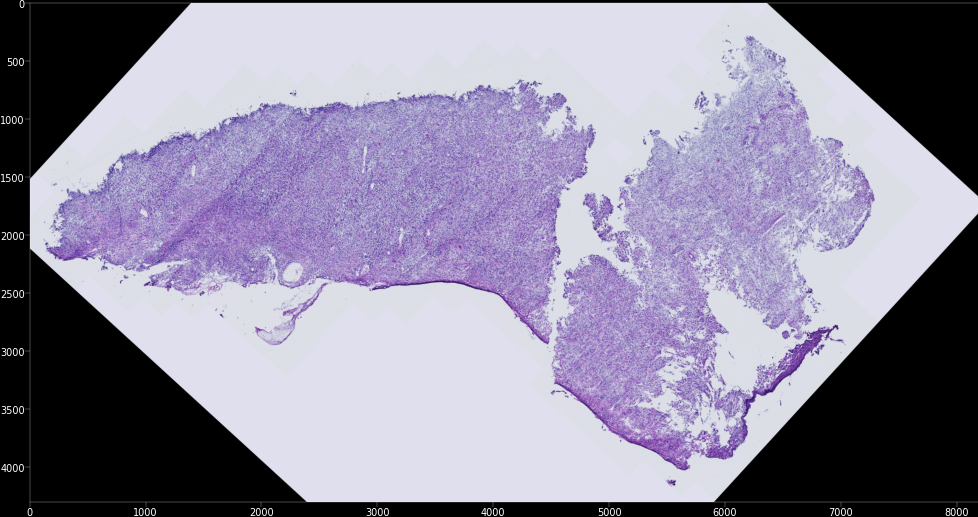

In [64]:
fig,ax = plt.subplots(1,1 ,figsize=(10,10))

sp.pl.plot_polygons(
    adata,
    sample='SL020',
    cluster_key='m-states',
    clusters=['FB-like 3'],
    show_axis=True,
    palette= palette_GW,
    image=np.array(HE_SL020),
    #xlim=xlim,
    #ylim=ylim,
    #flipy=False,
    #save = True,
    #savepath='figures/SL035B.svg',
    alpha=0,
    ax=ax
)

plt.show()

2025-10-28 14:25:34,102 - INFO - First filter, 1428 cells left
2025-10-28 14:25:34,125 - INFO - Selecting cells in zoom area
2025-10-28 14:25:34,154 - INFO - Zoom filter, 501 cells left


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


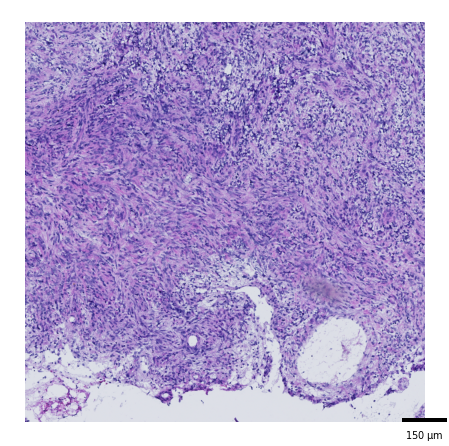

In [65]:
fig,ax = plt.subplots(1,1 ,figsize=(5,5))
xlim= (1500,2500)
ylim= (1500,2500)
sp.pl.plot_polygons(
    adata,
    sample='SL020',
    cluster_key='m-states',
    clusters=['FB-like 3'],
    show_axis=False,
    palette= palette_GW,
    image=np.array(HE_SL020),
    xlim=xlim,
    ylim=ylim,
    #flipy=False,
    #save = True,
    #savepath='figures/SL035B.svg',
    alpha=0,
    ax=ax
)
plt.savefig('figures/SL020_HE_zoom.png',dpi=300, format='png',bbox_inches='tight')
plt.show()


2025-10-28 14:25:36,633 - INFO - First filter, 12107 cells left
2025-10-28 14:25:36,808 - INFO - Selecting cells in zoom area
2025-10-28 14:25:36,973 - INFO - Zoom filter, 1019 cells left


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


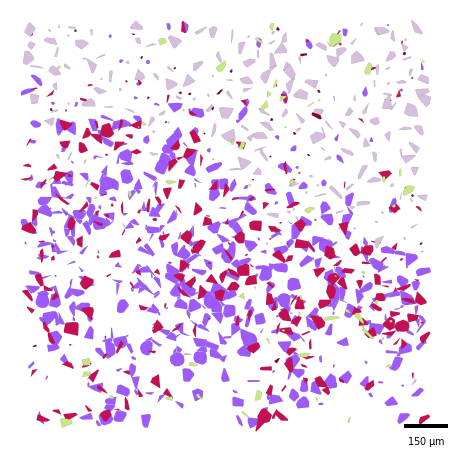

In [66]:
palette_GW = {
    'WR 2': '#EDE8F3',
    'WR 3': '#E2D8EA',
    'WR 1': '#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 7': '#e43c96',
    'WR 8': '#C50F53',
    'WR 4': '#A40447',
    'WR 6': '#840034',
    
    'Endothelial':'#C8E683', # '#d5b8ff',  
    'Mural': '#C8E683',
    
    'nIPC-RG-like':'#7dfee3',
    'FB-like 3': '#9f5afd',#'#ff9470',
    
}

fig,ax = plt.subplots(1,1 ,figsize=(5,5))
xlim= (1500,2500)
ylim= (1500,2500)
sp.pl.plot_polygons(
    adata,
    sample='SL020',
    cluster_key='m-states',
    clusters=['FB-like 3', 'WR 6', 'WR 8', 'WR 1','Endothelial'],
    show_axis=False,
    palette= palette_GW,
    image=np.array(HE_SL020),
    xlim=xlim,
    ylim=ylim,
    #flipy=False,
    #save = True,
    #savepath='figures/SL035B.svg',
    alpha_img=0,
    alpha=1,
    ax=ax
)
plt.savefig('figures/SL020_zoom.svg',dpi=300, format='png',bbox_inches='tight')
plt.show()


In [ ]:
from FISHscale.utils.dataset import Dataset
SL020 = Dataset('../../data_for_visualization/AMEXP20220311_EEL_SL020_S2_RNA_transformed_assigned.parquet',
             gene_label='decoded_genes',
             pixel_size='0.27 micrometers',
             reparse=True,
            )

'''SL020color_dict['VEGFA'] = np.array((227, 61, 148)) / 255
SL020color_dict['FTL'] = np.array((255, 255, 204)) / 255
SL020color_dict['IGFBP5'] = np.array((210, 77, 87)) / 255'''


 98%|███████████████████████████████████████▎| 876/890 [00:02<00:00, 403.68it/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|████████████████████████████████████████| 890/890 [00:02<00:00, 327.72it/s]


2025-10-28 14:25:49,303 - INFO -     Loaded: AMEXP20220311_EEL_SL020_S2_RNA_transformed_assigned


"SL020color_dict['VEGFA'] = np.array((227, 61, 148)) / 255\nSL020color_dict['FTL'] = np.array((255, 255, 204)) / 255\nSL020color_dict['IGFBP5'] = np.array((210, 77, 87)) / 255"

AttributeError: 'Legend' object has no attribute 'legendHandles'

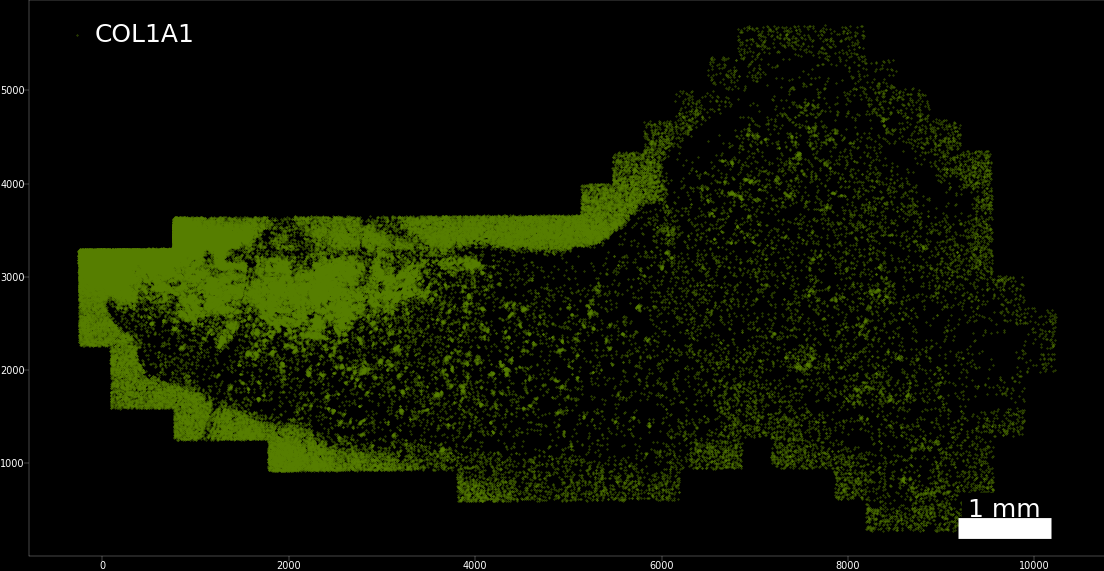

In [68]:
SL020.scatter_plot(
    'COL1A1',
    ax_scale_factor=50,
    show_axes=True,
)

In [69]:
SL020.color_dict['COL1A1'] = '#fffc7f'#palette_GW['FB-like 3']
SL020.color_dict['RGCC'] = '#c5eff7'#'#89c4f4'
SL020.color_dict['VEGFA'] = '#e76d89'#palette_GW['WR 7']
SL020.color_dict['MGP'] = '#d5b8ff' #palette_GW['WR 5']
SL020.color_dict['FN1'] = '#c3ff68' #palette_GW['Endothelial']
SL020.color_dict['AQP4'] =  '#26c281'
SL020.color_dict['PTPRZ1'] =  '#93faa5'
SL020.color_dict['S100B'] =  '#c2f970'

AttributeError: 'Legend' object has no attribute 'legendHandles'

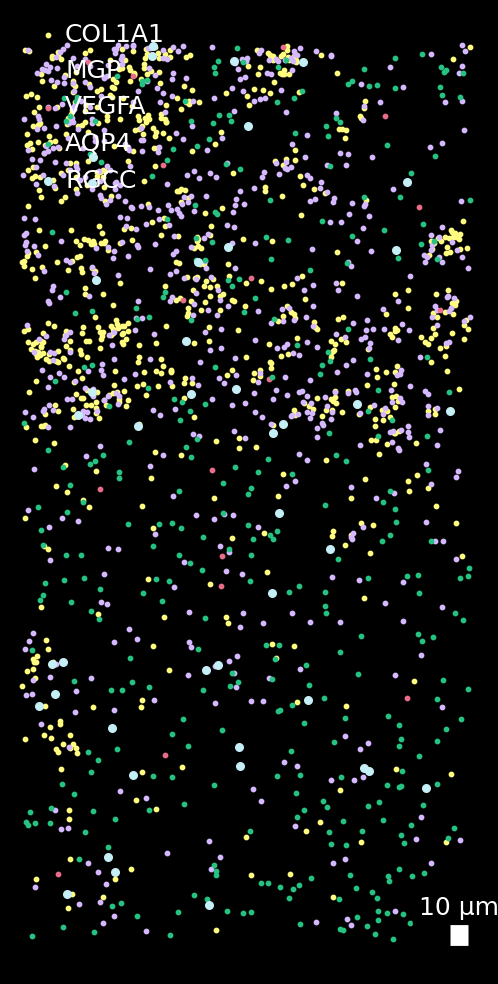

In [71]:
xlim= (3250,3500)
ylim= (2500,3000)

v =  [[xlim[0], ylim[0]],[xlim[1],ylim[1]]]

scale_factor = 1#0.27*4.5
#img_zoom = img_SL020[int(v[0][1]*scale_factor):int(v[1][1]*scale_factor),int(v[0][0]*scale_factor):int(v[1][0]*scale_factor)]

sizes = [10, 10, 10,10,30,10] 
genes = ['COL1A1', 'MGP','VEGFA','AQP4', 'RGCC']
SL020.scatter_plot(
    genes,
    s=sizes,
    ax_scale_factor=500,
    show_axes=False,
    show_legend=True,
    view = v,
    #image=img_zoom,
    alpha_img=.5,
    reset_xy=True,
    save=True,
    save_name='figures/SL020_zoom_dots.svg'
)